In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [2]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Basic Information

In [3]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (200, 4)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


Statistical Summary

In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


Correlation Analysis

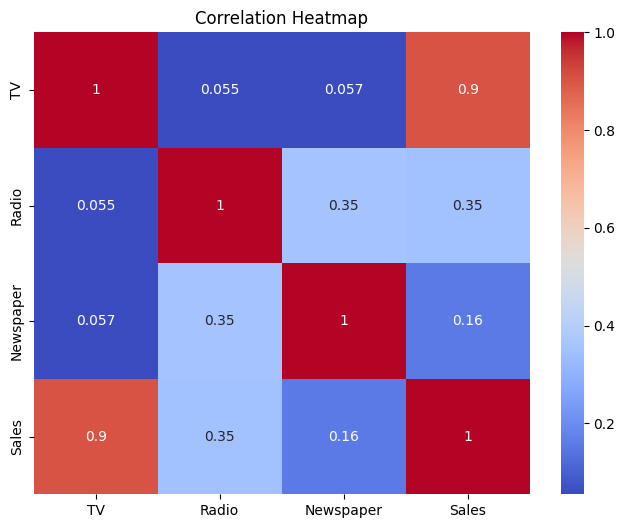

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

Pairplot

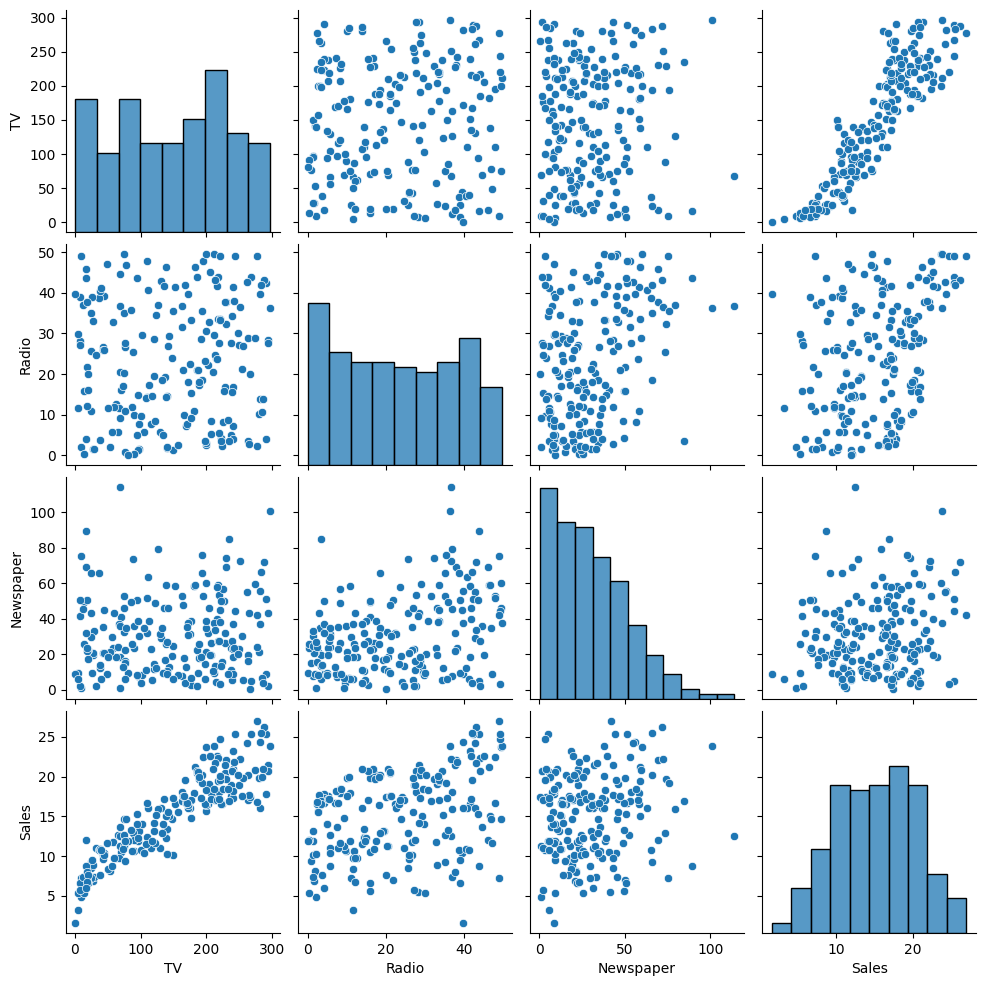

In [6]:
sns.pairplot(df)
plt.savefig("pairplot.png")
plt.show()

Distribution Plots

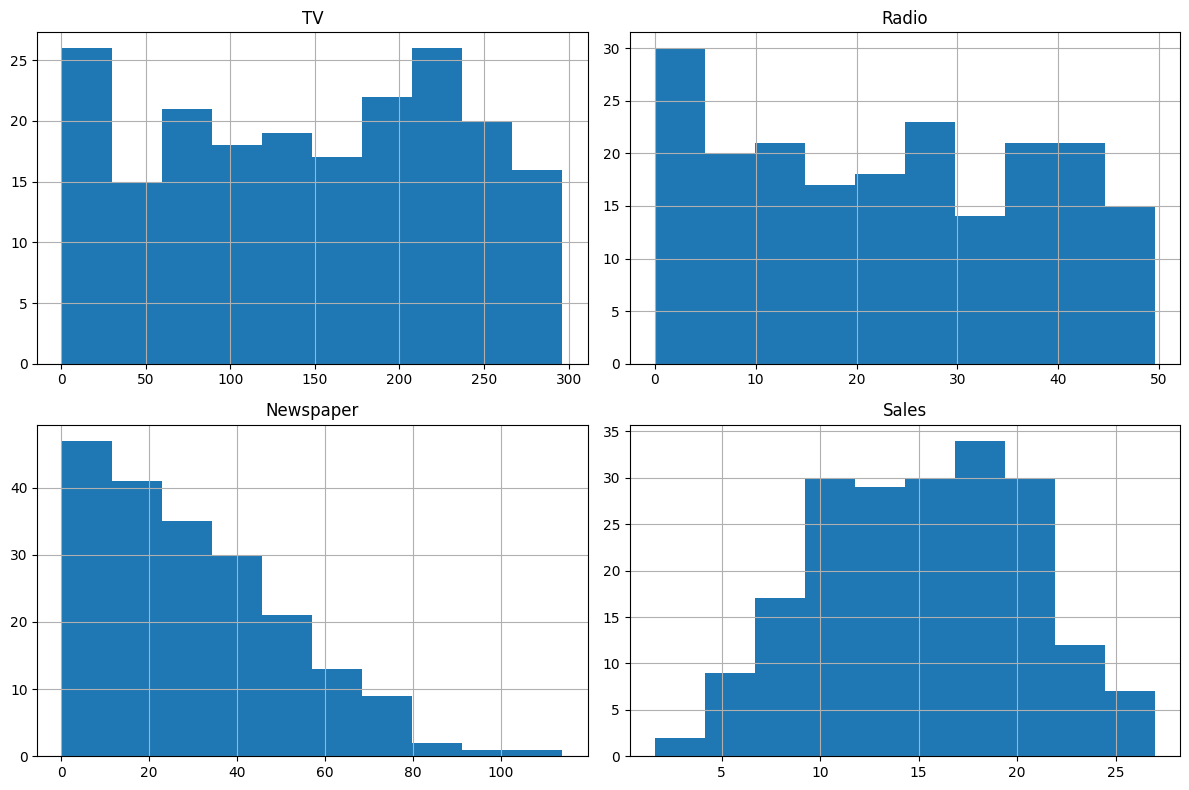

In [7]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Scatter Plots

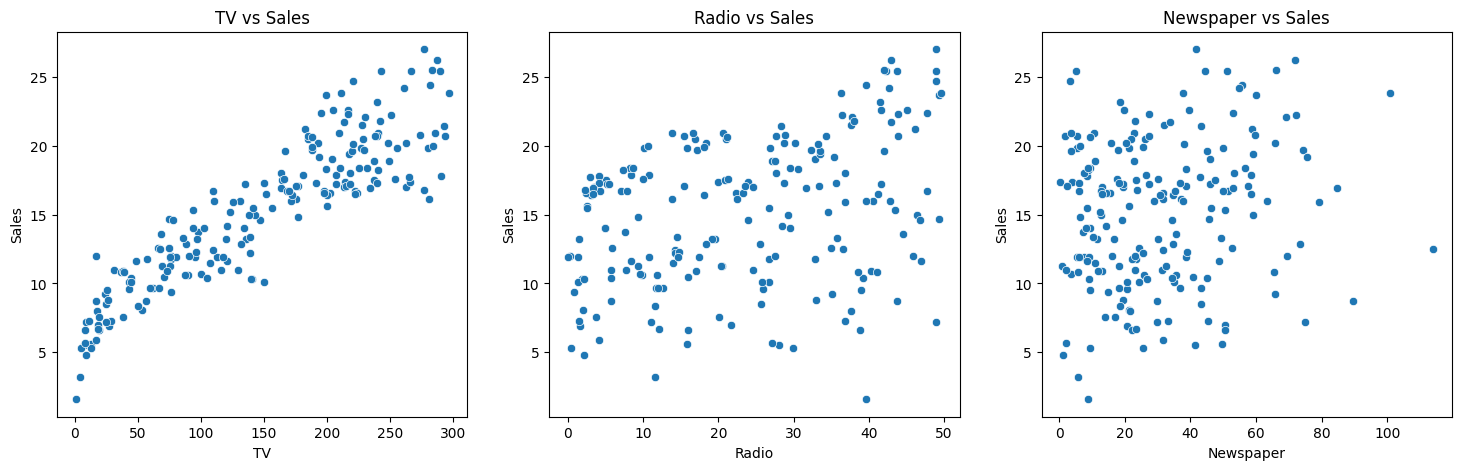

In [8]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
axes[0].set_title('TV vs Sales')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1])
axes[1].set_title('Radio vs Sales')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.show()

Feature Selection

In [9]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 160
Testing Samples: 40


Build and Train Model

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


Predictions

In [12]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

predictions.head()

,Actual,Predicted
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


Model Evaluation

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-"*30)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Model Evaluation Metrics
------------------------------
MAE  : 1.27
MSE  : 2.91
RMSE : 1.71
R² Score : 0.9059


 Actual vs Predicted Plot

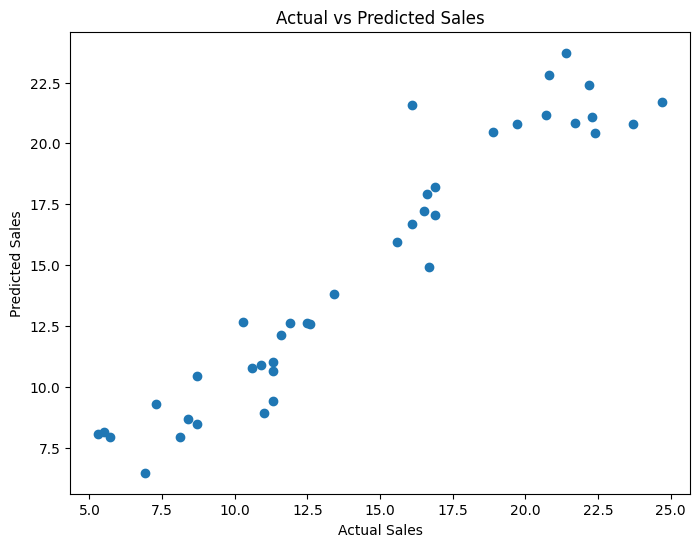

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.savefig("actual_vs_predicted.png")
plt.show()

Regression Plot

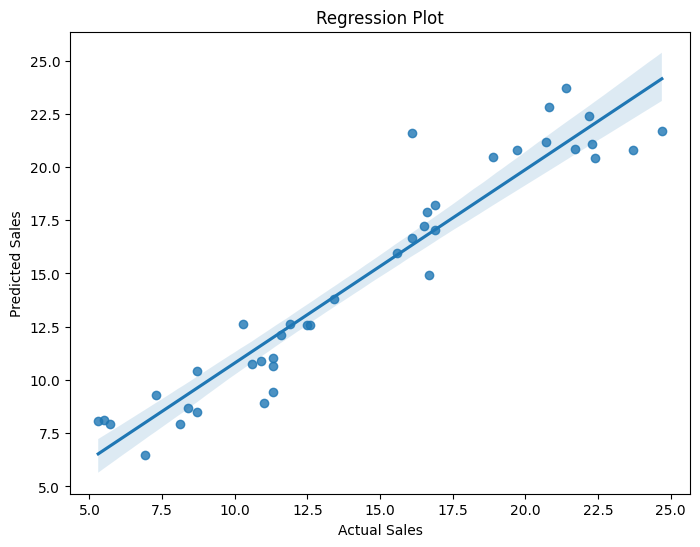

In [15]:
plt.figure(figsize=(8,6))

sns.regplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Regression Plot")

plt.savefig("regression_plot.png")
plt.show()

Feature Importance

     Feature  Coefficient
1      Radio     0.100945
0         TV     0.054509
2  Newspaper     0.004337


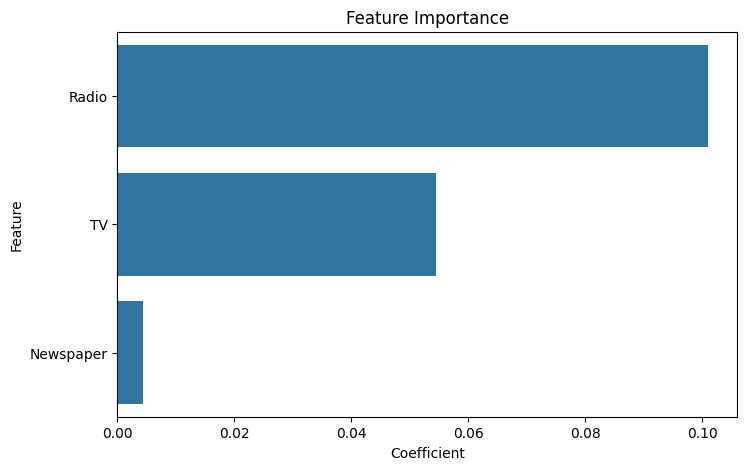

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Custom Prediction

In [18]:
# Example advertising budgets

tv_budget = 150
radio_budget = 25
newspaper_budget = 20

new_data = [[tv_budget, radio_budget, newspaper_budget]]

predicted_sales = model.predict(new_data)

print(f"Predicted Sales: {predicted_sales[0]:.2f}")

Predicted Sales: 15.50
